<a href="https://colab.research.google.com/github/coordinadorpf-prog/ModelosAnaliticosUnicafam202607/blob/main/Parcialfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODELO K-MEANS**

**PARCIAL FINAL**

**DIPLOMADO ANALITICA DE DATOS**

**UNICAFAM**

**ESTUDIANTES:**

**IVAN FELIPE REINA- DALIA ISABEL ZULUAGA**

In [10]:
# Paso 1. Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [14]:
# Paso 2. Importar el dataset
dataset=pd.read_excel("/content/sample_data/crime_data.xlsx",index_col=0)
dataset.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [15]:
# Paso 3. Seleccionar las columnas para determinar el cluster
X = dataset.values

scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393],
       [ 0.02597562,  0.40290872,  0.86954794,  1.88390137],
       [-1.04088037, -0.73648418,  0.79976079, -1.09272319],
       [-0.43787481,  0.81502956,  0.45082502, -0.58583422],
       [ 1.76541475,  1.99078607,  1.00912225,  1.1505301 ],
       [ 2.22926518,  0.48775713, -0.38662083,  0.49265293],
       [-0.57702994, -1.51224105,  1.21848371, -0.11129987],
       [-1.20322802, -0.61527217, -0.80534376, -0.75839217],
       [ 0.60578867,  0.94836277,  1.21848371,  0.29852525],
       [-0.13637203, -0.70012057, -0.03768506, -0.0250209 ],
       [-1.29599811, -1.39102904, -0.5959823 , -1.07115345],
       [-0.41468229, -0.67587817,  0.03210209, -0.34856705],
       [ 0.44344101, -0.

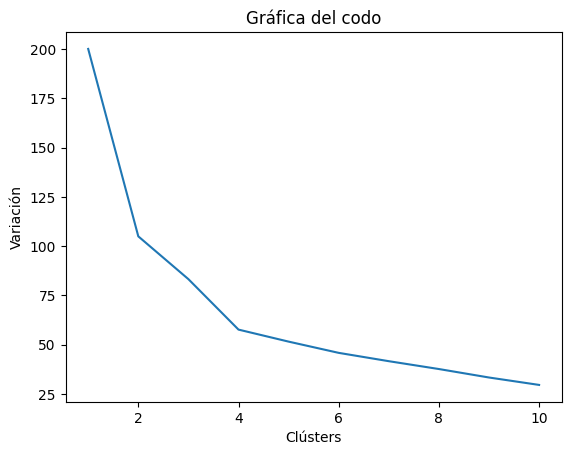

In [16]:
# Paso 4. Definición de cantidades optimas de
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Gráfica del codo
plt.plot(range(1, 11), wcss)
plt.title("Gráfica del codo")
plt.ylabel("Variación")
plt.xlabel("Clústers")
plt.show()

In [18]:
# Paso 5. Entrenamiento del modelo de clusterización
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 2,
       0, 1, 2, 0, 0, 2, 0, 0, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

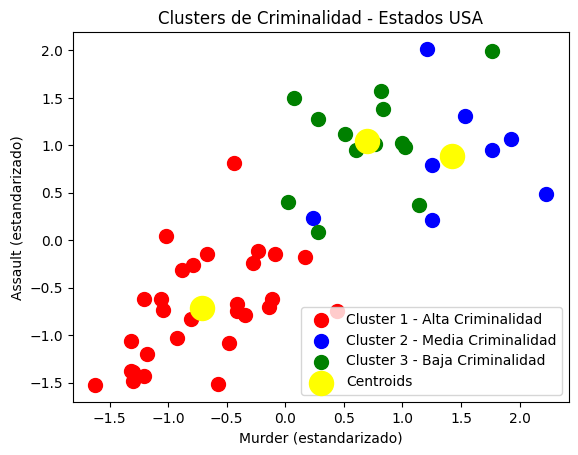

In [19]:
# Paso 6. Visualización de resultados
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 - Alta Criminalidad')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 - Media Criminalidad')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 - Baja Criminalidad')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters de Criminalidad - Estados USA')
plt.xlabel('Murder (estandarizado)')
plt.ylabel('Assault (estandarizado)')
plt.legend()
plt.show()

In [21]:
# Agregar los clusters al dataset

dataset["Cluster"] = y_kmeans
dataset

,Murder,Assault,UrbanPop,Rape,Cluster
Alabama,13.2,236,58,21.2,1
Alaska,10.0,263,48,44.5,2
Arizona,8.1,294,80,31.0,2
Arkansas,8.8,190,50,19.5,1
California,9.0,276,91,40.6,2
Colorado,7.9,204,78,38.7,2
Connecticut,3.3,110,77,11.1,0
Delaware,5.9,238,72,15.8,0
Florida,15.4,335,80,31.9,2
Georgia,17.4,211,60,25.8,1


In [22]:
dataset.to_csv("Resultados.csv",index=False)

In [23]:
# Ver estados por cluster
for i in range(3):
    estados = dataset[dataset['Cluster'] == i].index.tolist()
    print(f"\nCluster {i} ({len(estados)} estados):")
    print(', '.join(estados))
    print(f"Promedios:")
    print(dataset[dataset['Cluster'] == i][['Murder','Assault','UrbanPop','Rape']].mean().round(2))


Cluster 0 (29 estados):
Connecticut, Delaware, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Massachusetts, Minnesota, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming
Promedios:
Murder        4.73
Assault     111.83
UrbanPop     64.10
Rape         15.82
dtype: float64

Cluster 1 (8 estados):
Alabama, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee
Promedios:
Murder       13.94
Assault     243.62
UrbanPop     53.75
Rape         21.41
dtype: float64

Cluster 2 (13 estados):
Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Missouri, Nevada, New Mexico, New York, Texas
Promedios:
Murder       10.82
Assault     257.38
UrbanPop     76.00
Rape         33.19
dtype: float64


**Pregunta # 1 **
**¿Como podemos agrupar los estados?**

 R/ Los 50 estados se agruparon en 3 clusters según su nivel de criminalidad: Alta (8 estados), Media (13 estados) y Baja (29 estados), usando el algoritmo K-Means con K=3.

In [24]:
# PREGUNTA 1. ¿Cómo podemos agrupar los estados?
dataset['Nivel'] = dataset['Cluster'].map({
    1: 'ALTA Criminalidad',
    2: 'MEDIA Criminalidad',
    0: 'BAJA Criminalidad'
})
print(dataset.groupby('Nivel')[['Murder','Assault','UrbanPop','Rape']].mean().round(2))

                    Murder  Assault  UrbanPop   Rape
Nivel                                               
ALTA Criminalidad    13.94   243.62     53.75  21.41
BAJA Criminalidad     4.73   111.83     64.10  15.82
MEDIA Criminalidad   10.82   257.38     76.00  33.19


PREGUNTA 2. ¿Cuáles son los estados con necesidad de profesionales con mayor capacidad de atención
al crimen?
 R/:Los estados con mayor necesidad de profesionales especializados son los del Cluster 1 (ALTA Criminalidad): Alabama, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina y Tennessee. Estos presentan el mayor promedio de Murder (13.94) y Assault (243.62), por lo que requieren policías capacitados para atender casos de alta complejidad

In [25]:
# PREGUNTA 2. ¿Cuáles son los estados con mayor necesidad de profesionales?
print(dataset[dataset['Nivel'] == 'ALTA Criminalidad'][['Murder','Assault','UrbanPop','Rape']])

                Murder  Assault  UrbanPop  Rape
Alabama           13.2      236        58  21.2
Arkansas           8.8      190        50  19.5
Georgia           17.4      211        60  25.8
Louisiana         15.4      249        66  22.2
Mississippi       16.1      259        44  17.1
North Carolina    13.0      337        45  16.1
South Carolina    14.4      279        48  22.5
Tennessee         13.2      188        59  26.9


**PREGUNTA 3.¿Cómo distribuiría los recursos?**
Los recursos se distribuyen según el nivel de criminalidad de cada grupo. Los 300 policías especializados se asignan a los 8 estados de ALTA criminalidad (Murder: 13.94, Assault: 243.62), ya que son los casos más graves que requieren mayor capacidad. Los 500 policías de a pie se asignan a los 13 estados de MEDIA criminalidad (Murder: 10.82, Assault: 257.38), que aunque tienen altos asaltos, son más urbanos (76%) y requieren presencia en calle. Los 150 cadetes se asignan a los 29 estados de BAJA criminalidad (Murder: 4.73, Assault: 111.83), donde los casos son de menor complejidad y el riesgo es controlable.

In [27]:
# PREGUNTA 3. ¿Cómo distribuiría los recursos?
resumen = dataset.groupby('Nivel')[['Murder','Assault','UrbanPop','Rape']].mean().round(2)
conteo = dataset.groupby('Nivel').size().reset_index(name='Num_Estados')
print(resumen)
print(conteo)

                    Murder  Assault  UrbanPop   Rape
Nivel                                               
ALTA Criminalidad    13.94   243.62     53.75  21.41
BAJA Criminalidad     4.73   111.83     64.10  15.82
MEDIA Criminalidad   10.82   257.38     76.00  33.19
                Nivel  Num_Estados
0   ALTA Criminalidad            8
1   BAJA Criminalidad           29
2  MEDIA Criminalidad           13


**PREGUNTA 4.¿Cuáles son los grupos que existen dentro del comportamiento de la criminalidad?**
Se identificaron 3 grupos de comportamiento criminal. El grupo ALTA criminalidad (rojo) presenta el mayor índice de Murder con 13.94 y Assault de 243.62, concentrado en 8 estados del sur del país con baja urbanización (53.75%). El grupo MEDIA criminalidad (azul) tiene el Assault más alto de todos con 257.38 y el mayor índice de Rape (33.19), en 13 estados altamente urbanizados (76%). El grupo BAJA criminalidad (verde) con 29 estados muestra los valores más bajos en todos los indicadores, Murder 4.73 y Assault 111.83, siendo los estados más seguros.


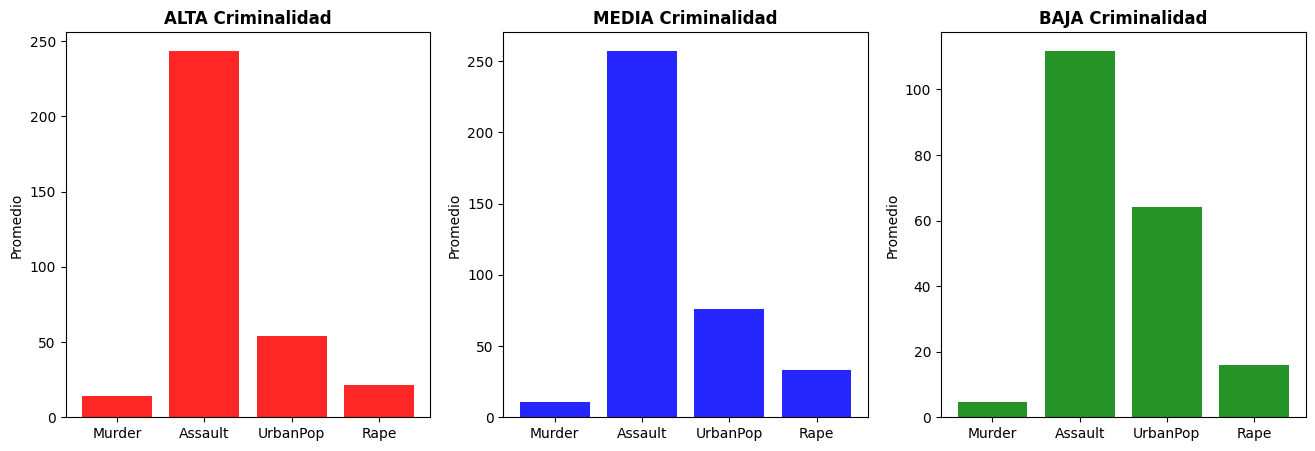

In [29]:
# PREGUNTA 4. Análisis de grupos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
niveles = ['ALTA Criminalidad', 'MEDIA Criminalidad', 'BAJA Criminalidad']
colores = ['red', 'blue', 'green']

for ax, nivel, color in zip(axes, niveles, colores):
    medias = dataset[dataset['Nivel'] == nivel][['Murder','Assault','UrbanPop','Rape']].mean()
    ax.bar(medias.index, medias.values, color=color, alpha=0.85)
    ax.set_title(nivel, fontweight='bold')
    ax.set_ylabel('Promedio')

plt.show()

**PREGUNTA 5 Recomendaciones finales**
Con base en el análisis de clustering se recomienda: Asignar los 300 policías especializados a los 8 estados de ALTA criminalidad priorizando Alabama, Mississippi y North Carolina que presentan los mayores índices de Murder y Assault. Los 500 policías de a pie deben concentrarse en los 13 estados de MEDIA criminalidad especialmente en estados urbanos como California, Texas y Nueva York donde el Rape y Assault son más altos. Los 150 cadetes se distribuyen en los 29 estados de BAJA criminalidad para mantener presencia preventiva. Se recomienda revisar la asignación de recursos cada trimestre según la evolución de los indicadores.